In [4]:
# Importación del ecosistema de desarrollo para IA
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

print("Versión de TensorFlow en ejecución:", tf.__version__)

Versión de TensorFlow en ejecución: 2.20.0


# Problemas Resueltos

## 1. Curva de Saturación y Eficiencia de un Amplificador de Alta Potencia (HPA)
**Propósito:** Demostrar cómo una red neuronal rompe la linealidad utilizando capas ocultas y funciones de activación (**ReLU**), abordando un problema donde la escala nativa de los datos hace innecesaria una capa de normalización.

En las estaciones terrenas de telecomunicaciones espaciales, los Amplificadores de Alta Potencia (HPA) presentan un comportamiento fuertemente no lineal. Cuando el voltaje de la señal de entrada ($X$) es bajo, el componente opera en su **zona lineal** (la eficiencia sube proporcionalmente). Sin embargo, al aproximarse a su punto de compresión, el amplificador entra en **zona de saturación**, provocando que la eficiencia ($Y$) se aplane y forme un techo máximo.

### 💡 Nota sobre la Escala de los Datos:
A diferencia del ejemplo del sensor, aquí las variables de entrada ya operan por su propia naturaleza física en un rango numérico ideal (Voltajes de $0.0$ a $5.0\text{ V}$). Al inyectar magnitudes tan pequeñas, los gradientes matemáticos no corren riesgo de desbordarse, permitiendo que las neuronas procesen los datos crudos directamente sin requerir una capa intermedia de normalización estadística.

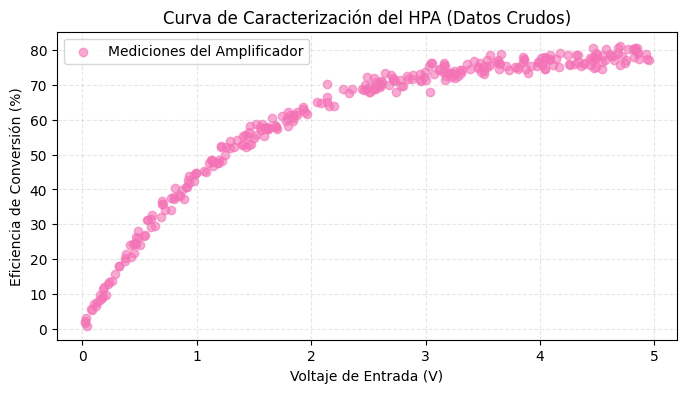

In [5]:
# Simulación de la curva de eficiencia física de un amplificador HPA
# El voltaje (X) opera de 0 a 5 Voltios. La eficiencia (Y) satura exponencialmente cerca del 80%
np.random.seed(42)
voltaje_raw = np.random.uniform(0.0, 5.0, 300)

# Ecuación física de saturación para generar el comportamiento del componente
eficiencia_y = 80.0 * (1.0 - np.exp(-0.8 * voltaje_raw)) + np.random.normal(0, 1.5, 300)

# Ajuste dimensional requerido por Keras para variables de entrada: (Muestras, 1)
voltaje_train_reshaped = voltaje_raw.reshape(-1, 1).astype('float32')

# Visualización del comportamiento del componente de telecomunicaciones
plt.figure(figsize=(8, 4))
plt.scatter(voltaje_raw, eficiencia_y, color='#f472b6', alpha=0.6, label='Mediciones del Amplificador')
plt.title('Curva de Caracterización del HPA (Datos Crudos)')
plt.xlabel('Voltaje de Entrada (V)')
plt.ylabel('Eficiencia de Conversión (%)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.show()

In [6]:
# =====================================================================
# ETAPA A: DEFINICIÓN ARQUITECTÓNICA DE LA RED NO LINEAL (CORREGIDA)
# =====================================================================
model_hpa = keras.Sequential([
    # Usamos 'tanh' para garantizar que las neuronas tengan gradientes activos en todo el rango [0, 5]
    keras.layers.Dense(units=16, activation='tanh', input_shape=[1]),
    keras.layers.Dense(units=8, activation='tanh'),
    # Capa de salida lineal para predecir la eficiencia
    keras.layers.Dense(units=1)
])

# =====================================================================
# ETAPA B: PREPARACIÓN PARA LA COMPILACIÓN Y ENTRENAMIENTO
# =====================================================================
model_hpa.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss='mean_squared_error'
)

print("Entrenando la red con funciones continuas...")
# Subimos las épocas para asegurar que el optimizador mapée la curva por completo
history_hpa = model_hpa.fit(voltaje_train_reshaped, eficiencia_y, epochs=600, verbose=0)
print("¡Entrenamiento completado!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando la red con funciones continuas...
¡Entrenamiento completado!


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


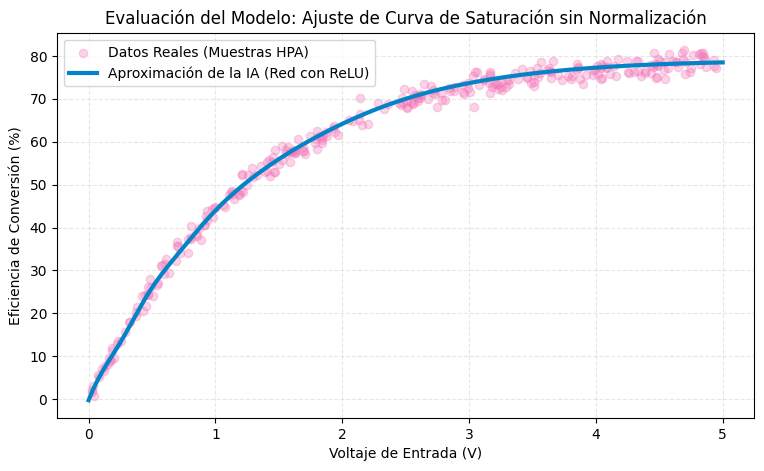

In [7]:
# Generamos un vector ordenado de voltajes de prueba para evaluar la respuesta de la IA
voltaje_test = np.linspace(0.0, 5.0, 200).reshape(-1, 1)
predicciones_eficiencia = model_hpa.predict(voltaje_test)

# Graficado final superponiendo la predicción del modelo sobre los datos reales
plt.figure(figsize=(9, 5))
plt.scatter(voltaje_raw, eficiencia_y, color='#f472b6', alpha=0.3, label='Datos Reales (Muestras HPA)')
plt.plot(voltaje_test, predicciones_eficiencia, color='#0284c7', lw=3, label='Aproximación de la IA (Red con ReLU)')
plt.title('Evaluación del Modelo: Ajuste de Curva de Saturación sin Normalización')
plt.xlabel('Voltaje de Entrada (V)')
plt.ylabel('Eficiencia de Conversión (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# Problemas propuestos

## 1. Reto Autónomo: Estimación de la Densidad Atmosférica Local en Órbita Baja (LEO)
**Propósito:** Desarrollar intuición en el diseño de redes mediante el uso de múltiples variables de entrada (**Regresión Multivariable**).

**Enunciado:** La densidad de la alta atmósfera decrece exponencialmente con la altitud y varía de forma violenta según el nivel de irradiación o actividad solar, afectando directamente el decaimiento de satélites en órbitas bajas.

Utilizando el set de datos sintéticos preconfigurado en la celda de abajo, tu misión consiste en diseñar, compilar y entrenar una red neuronal capaz de predecir la **Densidad Atmosférica Oculta**.

### Instrucciones Técnicas del Reto:
1. Diseña una red con **al menos dos capas ocultas** interconectadas en la sección de Definición Arquitectónica.
2. Configura un optimizador `Adam` y la función de pérdida pertinente para problemas de estimación continua.
3. Ajusta el número de neuronas e hiperparámetros hasta lograr que la curva de error se estabilice limpiamente cerca de cero sin oscilaciones bruscas.

In [ ]:
# PREPARACIÓN AUTOMÁTICA DEL CONTEXTO DEL RETO (NO MODIFICAR ESTA CELDA)
num_muestras = 1000
altitud = np.random.uniform(200, 600, num_muestras)   # Entrada 1: Altitud en km
act_solar = np.random.uniform(70, 250, num_muestras)  # Entrada 2: Flujo Solar F10.7

# Variable física objetivo calculada de forma no lineal compleja
densidad_objetivo = (1000 / altitud**2) * (act_solar / 100)

# Empaquetamiento matricial de variables de entrada (X)
X_reto = np.column_stack((altitud, act_solar))
Y_reto = densidad_objetivo

print("Estructura dimensional de la matriz de entrada (X):", X_reto.shape)
print("Estructura dimensional del vector objetivo (Y):      ", Y_reto.shape)
print("\n--> ¡Todo listo! Diseña tu arquitectura en la siguiente celda de código.")

In [ ]:
# =====================================================================
# DESARROLLO DEL PARTICIPANTE - COMPLETA LOS BLOQUES DE CÓDIGO
# =====================================================================

# 1. ETAPA A: DEFINICIÓN ARQUITECTÓNICA DE LA RED MULTIVARIABLE
model_reto = keras.Sequential([
    # NOTA: La propiedad input_shape ahora debe ser [2] porque procesamos 2 variables de entrada.
    # REQUERIMIENTO: Añade aquí tus capas ocultas densas con funciones de activación ReLU.

    keras.layers.Dense(units=1) # Capa de salida para 1 magnitud continua
])

# 2. ETAPA B: PREPARACIÓN PARA LA COMPILACIÓN
model_reto.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01), # Puedes experimentar con este parámetro
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

# 3. EJECUCIÓN DEL ENTRENAMIENTO (Descomenta la línea de abajo cuando completes tu arquitectura)
# history_reto = model_reto.fit(X_reto, Y_reto, epochs=100, verbose=1)